# ISLES'22 Veri Hazirlik - Parca 2

`PLAN.md` Bolum 2'deki dort karari uygular ve egitime hazir onbellegi uretir.

| Adim | Ne | Neden (Parca 1 olcumu) |
|---|---|---|
| 1 | **ADC olcek duzeltmesi** | ADC p99 = 1163 +- 1704; veri en az uc birimde geliyor |
| 2 | **2x2x2 mm izotropik resample** | 7 farkli spacing, 52 vaka 4.8 mm dilim |
| 3 | Beyin maskesi + bbox kirpma | beyin hacmin %18.8'i |
| 4 | DWI z-score, ADC klip+olcek | DWI keyfi olcek, ADC fizik birimli |
| 5 | `.npy` onbellek | Drive'dan tekrar `.nii.gz` acmamak icin |
| 6 | `split.json` | merkez x hacim tertili, vaka bazli, bos maskeli 3 vaka yalniz train |
| 7 | `eval_cases.json` | tum modellerde ortak 5 sabit test vakasi |

**FLAIR bu parcada hazirlanmiyor.** DWI ile ayni uzayda olmadigi (0/250) icin vaka basina
kayit gerekiyor; bu maliyet A1 ablasyonuna ait ve orada olculecek.

Cikti: `MyDrive/iskemik_inme/hazir/` + `split.json` + `eval_cases.json` + `hazir/config.json`

In [2]:
import os, glob, json, re, collections, time
from pathlib import Path

ORTAM = 'colab' if os.path.isdir('/content') else 'yerel'


def drive_bagla(nokta='/content/drive'):
    '''Colab'da Drive'i baglar. Onceki oturum koptuysa mount noktasi bayat dosyalarla
    dolu kalir ve duz mount() 'Mountpoint must not already contain files' hatasi verir;
    o durumda force_remount denenir.'''
    if ORTAM != 'colab':
        return None
    from google.colab import drive
    if os.path.ismount(nokta):
        print('Drive zaten bagli:', nokta)
        return nokta
    try:
        drive.mount(nokta)
    except ValueError as e:
        print('duz mount basarisiz (%s) -> force_remount' % e)
        drive.mount(nokta, force_remount=True)
    return nokta


drive_bagla()

PROJE = '/content/drive/MyDrive/iskemik_inme' if ORTAM == 'colab' else str(Path.cwd())
DATA_ROOT = os.path.join(PROJE, 'ISLES-2022') if os.path.isdir(os.path.join(PROJE, 'ISLES-2022')) else PROJE
HAZIR = os.path.join(PROJE, 'hazir')
OZET_DIR = os.path.join(PROJE, 'ozet')
os.makedirs(HAZIR, exist_ok=True)
print('PROJE:', PROJE)
print('DATA_ROOT:', DATA_ROOT)
print('HAZIR:', HAZIR)

Mounted at /content/drive
PROJE: /content/drive/MyDrive/iskemik_inme
DATA_ROOT: /content/drive/MyDrive/iskemik_inme/ISLES-2022
HAZIR: /content/drive/MyDrive/iskemik_inme/hazir


In [3]:
try:
    import nibabel as nib
except ImportError:
    os.system('pip -q install nibabel')
    import nibabel as nib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage
from nibabel.processing import resample_to_output

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)
print('nibabel:', nib.__version__, '| numpy:', np.__version__)

nibabel: 5.4.2 | numpy: 2.1.3


## Konfigurasyon

Tum sabitler burada; `hazir/config.json` olarak yazilir ve sonraki parcalar bunu okur.

In [4]:
CFG = dict(
    hedef_spacing=(2.0, 2.0, 2.0),   # Parca 1: 193/250 vaka zaten burada
    resample_order_goruntu=1,        # trilinear
    resample_order_maske=0,          # nearest
    beyin_esik_carpani=0.05,         # DWI p99 x bu -> beyin esigi
    kirpma_marji=4,                  # bbox etrafinda voxel payi
    adc_klip=3200.0,                 # x10^-6 mm2/s, ustu CSF/artefakt
    dwi_z_klip=5.0,                  # z-score sonrasi simetrik klip
    seed=42,
    test_orani=0.20,
    val_orani=0.20,                  # train+val icinden
    dtype_goruntu='float16',
    dtype_maske='uint8',
)
np.random.seed(CFG['seed'])
for k, v in CFG.items():
    print(f'{k:24s} {v}')

hedef_spacing            (2.0, 2.0, 2.0)
resample_order_goruntu   1
resample_order_maske     0
beyin_esik_carpani       0.05
kirpma_marji             4
adc_klip                 3200.0
dwi_z_klip               5.0
seed                     42
test_orani               0.2
val_orani                0.2
dtype_goruntu            float16
dtype_maske              uint8


## 1. Dosya envanteri (Parca 1 ile ayni mantik)

In [5]:
VAKA_RE = re.compile(r'(sub-[A-Za-z0-9]+)')
SERILER = ['dwi', 'adc']

tum = [p for p in glob.glob(os.path.join(DATA_ROOT, '**', '*'), recursive=True) if os.path.isfile(p)]
NII = [p for p in tum if p.lower().endswith('.nii.gz')]
vakalar = sorted({m for p in tum for m in VAKA_RE.findall(p)})

def seri_turu(yol):
    ad = os.path.basename(yol).lower().replace('.nii.gz', '')
    for s in SERILER:
        if ad.endswith('_' + s):
            return s
    if ad.endswith('_msk'):
        return 'msk'
    return None

kayit = {v: {'vaka': v, 'dwi': None, 'adc': None, 'msk': None} for v in vakalar}
for q in NII:
    v = next(iter(VAKA_RE.findall(q)), None)
    t = seri_turu(q)
    if v and t:
        kayit[v][t] = q

dosya = pd.DataFrame([kayit[v] for v in vakalar])
print('vaka:', len(dosya))
print(dosya[SERILER + ['msk']].notna().sum().to_string())
assert dosya[SERILER + ['msk']].notna().all().all(), 'eksik seri var'

# merkez
mrk = pd.read_excel(os.path.join(PROJE, 'center_ids.xlsx'))
mrk.columns = ['vaka', 'merkez']
dosya = dosya.merge(mrk, on='vaka', how='left')
print('\nmerkez:', dosya.merkez.value_counts().to_dict())

vaka: 250
dwi    250
adc    250
msk    250

merkez: {1: 198, 2: 52}


## 2. ADC olcek tespiti - Parca 1 karar 2

Beyin ici ADC'nin ust degeri uc ayri buyukluk mertebesinde geliyor. Her vakayi olcup
ortak birime (`x10^-6 mm2/s`) tasiyacak carpani belirliyoruz.

Beyin dokusunda ADC ~ 0,7-1,0 x10^-3 mm2/s, BOS ~ 3 x10^-3. Yani ortak birimde ust sinir
~3000-4000. Buna gore:

| Beyin ici max ADC | Yorumlanan birim | Carpan |
|---|---|---|
| < 0,05 | mm2/s | 1e6 |
| < 50 | x10^-3 mm2/s | 1e3 |
| aksi | x10^-6 mm2/s | 1 |

In [6]:
def beyin_maskesi(dw):
    esik = np.percentile(dw, 99) * CFG['beyin_esik_carpani']
    b = dw > esik
    b = ndimage.binary_closing(b, np.ones((3, 3, 3)))
    b = ndimage.binary_fill_holes(b)
    et, n = ndimage.label(b)
    if n > 1:                                  # en buyuk bileseni tut (boyun/goz artefakti)
        b = et == (np.bincount(et.ravel())[1:].argmax() + 1)
    return b


def adc_carpan(mx):
    if mx < 0.05:
        return 1e6, 'mm2/s'
    if mx < 50:
        return 1e3, 'x10-3'
    return 1.0, 'x10-6'


olcek = []
t0 = time.time()
for i, r in dosya.iterrows():
    dw = np.asarray(nib.load(r.dwi).dataobj).astype(np.float32)
    ad = np.asarray(nib.load(r.adc).dataobj).astype(np.float32)
    b = beyin_maskesi(dw)
    mx = float(np.percentile(ad[b], 99.9))
    c, ad_birim = adc_carpan(mx)
    olcek.append(dict(vaka=r.vaka, adc_p999_ham=mx, carpan=c, birim=ad_birim,
                      adc_p999_ortak=mx * c, beyin_orani=float(b.mean())))
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(dosya)}  ({time.time()-t0:.0f} sn)')

olcek = pd.DataFrame(olcek)
dosya = dosya.merge(olcek[['vaka', 'carpan', 'birim']], on='vaka')
print('\nbirim dagilimi:')
print(olcek.birim.value_counts().to_string())
print('\nDONUSUM ONCESI  adc p99.9 (ham):')
print(olcek.adc_p999_ham.describe().to_string())
print('\nDONUSUM SONRASI adc p99.9 (ortak birim x10^-6):')
print(olcek.adc_p999_ortak.describe().to_string())

  50/250  (204 sn)
  100/250  (396 sn)
  150/250  (592 sn)
  200/250  (703 sn)
  250/250  (841 sn)

birim dagilimi:
birim
mm2/s    106
x10-6     76
x10-3     68

DONUSUM ONCESI  adc p99.9 (ham):
count     250.000000
mean     1228.256118
std      1866.386450
min         0.003187
25%         0.003561
50%         3.704754
75%      3744.529419
max      4573.885254

DONUSUM SONRASI adc p99.9 (ortak birim x10^-6):
count     250.000000
mean     3830.361198
std       335.628030
min      3187.086433
25%      3561.040154
50%      3701.318979
75%      4095.000000
max      4573.885254


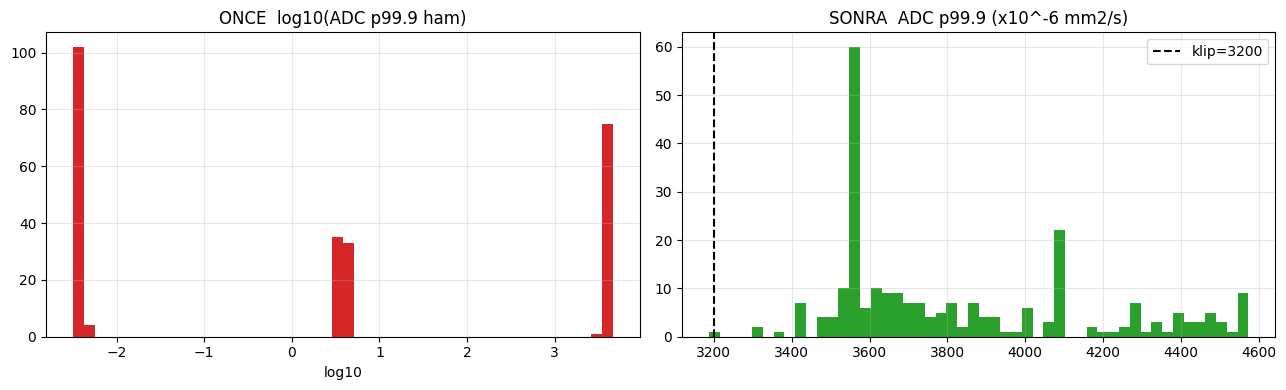

donusum sonrasi varyasyon katsayisi: 0.088
aykiri vakalar (ortak birimde p99.9 < 500 veya > 6000):
Empty DataFrame
Columns: [vaka, adc_p999_ham, carpan, birim, adc_p999_ortak, beyin_orani]
Index: []


In [7]:
# Dogrulama: donusum sonrasi dagilim TEK moda dusmeli. Genis kalirsa esikler yanlis.
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(np.log10(olcek.adc_p999_ham.clip(lower=1e-6)), bins=50, color='tab:red')
ax[0].set_title('ONCE  log10(ADC p99.9 ham)'); ax[0].set_xlabel('log10'); ax[0].grid(alpha=.3)
ax[1].hist(olcek.adc_p999_ortak, bins=50, color='tab:green')
ax[1].set_title('SONRA  ADC p99.9 (x10^-6 mm2/s)'); ax[1].grid(alpha=.3)
ax[1].axvline(CFG['adc_klip'], color='k', ls='--', label=f"klip={CFG['adc_klip']:.0f}")
ax[1].legend()
plt.tight_layout(); plt.savefig(os.path.join(OZET_DIR, 'adc_olcek_duzeltme.png'), dpi=130); plt.show()

cv = olcek.adc_p999_ortak.std() / olcek.adc_p999_ortak.mean()
print(f'donusum sonrasi varyasyon katsayisi: {cv:.3f}')
print('aykiri vakalar (ortak birimde p99.9 < 500 veya > 6000):')
print(olcek[(olcek.adc_p999_ortak < 500) | (olcek.adc_p999_ortak > 6000)].to_string(index=False))
if cv > 0.5:
    print('\n!! Dagilim hala genis - esikler gozden gecirilmeli.')

## 3. Ön isleme hatti

Sira onemli: **once resample, sonra beyin maskesi ve kirpma** - maske hedef grid'de
hesaplanirsa kirpma kutusu ile kaydedilen dizi birebir ortusuyor.

`resample_to_output` cikti grid'ini affine'den turetir; DWI/ADC/maske ayni affine'e sahip
oldugu icin uc cikti da ayni grid'e duser. Ayrica yonelimi de normalize eder - vakalar arasi
yon farki kalmaz.

Hacim (mL) **orijinal spacing'den** hesaplanip manifest'e yazilir; klinik buyuk resample'dan
etkilenmemeli. Resample sonrasi hacim de yazilir, ikisi karsilastirilir.

In [8]:
def hazirla(r):
    dwi_im, adc_im, msk_im = nib.load(r.dwi), nib.load(r.adc), nib.load(r.msk)
    zoom0 = dwi_im.header.get_zooms()[:3]
    m0 = np.asarray(msk_im.dataobj) > 0.5
    hacim_ml_orijinal = float(m0.sum()) * float(np.prod(zoom0)) / 1000.0

    # 1) resample -> ortak grid + yonelim normalizasyonu
    hs = CFG['hedef_spacing']
    dw = np.asarray(resample_to_output(dwi_im, hs, order=CFG['resample_order_goruntu']).dataobj).astype(np.float32)
    ad = np.asarray(resample_to_output(adc_im, hs, order=CFG['resample_order_goruntu']).dataobj).astype(np.float32)
    mk = np.asarray(resample_to_output(msk_im, hs, order=CFG['resample_order_maske']).dataobj) > 0.5
    assert dw.shape == ad.shape == mk.shape, f'{r.vaka}: resample sonrasi sekil uyusmuyor'

    # 2) beyin maskesi + bbox kirpma
    b = beyin_maskesi(dw)
    idx = np.where(b)
    m = CFG['kirpma_marji']
    dilim = tuple(slice(max(int(i.min()) - m, 0), min(int(i.max()) + 1 + m, s))
                  for i, s in zip(idx, dw.shape))
    dw, ad, mk, b = dw[dilim], ad[dilim], mk[dilim], b[dilim]

    # 3) yogunluk normalizasyonu
    ad = ad * r.carpan                                   # ortak birim
    ad = np.clip(ad, 0, CFG['adc_klip']) / CFG['adc_klip']   # [0,1]
    ort, std = float(dw[b].mean()), float(dw[b].std()) + 1e-6
    dw = np.clip((dw - ort) / std, -CFG['dwi_z_klip'], CFG['dwi_z_klip'])
    dw[~b] = 0.0                                          # beyin disi sifir
    ad[~b] = 0.0

    x = np.stack([dw, ad]).astype(CFG['dtype_goruntu'])    # (2, H, W, D)
    y = mk.astype(CFG['dtype_maske'])
    bm = b.astype(np.uint8)

    voxel_ml = float(np.prod(hs)) / 1000.0
    return x, y, bm, dict(
        vaka=r.vaka, merkez=int(r.merkez), birim=r.birim,
        sekil='x'.join(map(str, x.shape[1:])),
        H=x.shape[1], W=x.shape[2], D=x.shape[3],
        hacim_ml=round(hacim_ml_orijinal, 4),
        hacim_ml_resample=round(float(y.sum()) * voxel_ml, 4),
        lezyonlu_dilim=int((y.sum(axis=(0, 1)) > 0).sum()),
        beyin_orani=round(float(bm.mean()), 4),
        bos_maske=bool(y.sum() == 0),
    )

# tek vakada dene
x, y, bm, bilgi = hazirla(dosya.iloc[0])
print(bilgi)
print('x', x.shape, x.dtype, 'DWI araligi', float(x[0].min()), float(x[0].max()),
      '| ADC araligi', float(x[1].min()), float(x[1].max()))
print('y', y.shape, y.dtype, 'benzersiz', np.unique(y))

{'vaka': 'sub-strokecase0001', 'merkez': 1, 'birim': 'x10-3', 'sekil': '72x85x74', 'H': 72, 'W': 85, 'D': 74, 'hacim_ml': 6.68, 'hacim_ml_resample': 6.616, 'lezyonlu_dilim': 48, 'beyin_orani': 0.3359, 'bos_maske': False}
x (2, 72, 85, 74) float16 DWI araligi -2.466796875 5.0 | ADC araligi 0.0 1.0
y (72, 85, 74) uint8 benzersiz [0 1]


In [9]:
manifest = []
t0 = time.time()
for i, r in dosya.iterrows():
    try:
        x, y, bm, bilgi = hazirla(r)
        np.save(os.path.join(HAZIR, f'{r.vaka}_x.npy'), x)
        np.save(os.path.join(HAZIR, f'{r.vaka}_y.npy'), y)
        np.save(os.path.join(HAZIR, f'{r.vaka}_b.npy'), bm)
        manifest.append(bilgi)
    except Exception as e:
        print('HATA', r.vaka, repr(e))
    if (i + 1) % 25 == 0:
        gecen = time.time() - t0
        print(f'  {i+1}/{len(dosya)}  {gecen:.0f} sn  (kalan ~{gecen/(i+1)*(len(dosya)-i-1):.0f} sn)')

man = pd.DataFrame(manifest)
print('\nhazirlanan vaka:', len(man))
print('toplam onbellek:',
      f"{sum(os.path.getsize(os.path.join(HAZIR, f)) for f in os.listdir(HAZIR) if f.endswith('.npy'))/1e9:.2f} GB")

  25/250  70 sn  (kalan ~629 sn)
  50/250  138 sn  (kalan ~552 sn)
  75/250  207 sn  (kalan ~482 sn)
  100/250  276 sn  (kalan ~414 sn)
  125/250  345 sn  (kalan ~345 sn)
  150/250  414 sn  (kalan ~276 sn)
  175/250  481 sn  (kalan ~206 sn)
  200/250  547 sn  (kalan ~137 sn)
  225/250  614 sn  (kalan ~68 sn)
  250/250  680 sn  (kalan ~0 sn)

hazirlanan vaka: 250
toplam onbellek: 1.07 GB


## 4. Girdi boyutu karari

Kirpma sonrasi duzlem boyutlari degisken. Modele sabit boyut gerekiyor; dolgu Dataset icinde
yapilacak, onbellekte gereksiz sifir tutulmayacak. Hedef boyut = 99. persentilin ustundeki
ilk 32'nin kati - hem encoder stride'larina bolunur hem vakalarin %99'unu kirpmadan alir.

In [10]:
print(man[['H', 'W', 'D']].describe(percentiles=[.5, .9, .99]).to_string())

def yukari32(v):
    return int(np.ceil(v / 32.0) * 32)

# Eksen basina ayri: H ve W dagilimlari farkli, kare boyut gereksiz dolgu demek.
# 32'nin kati sart - ResNet/EffNet encoder'lari 32 kat asagi ornekliyor.
H_HEDEF = yukari32(man.H.max())
W_HEDEF = yukari32(man.W.max())
print()
print(f'H: max {int(man.H.max())} -> {H_HEDEF}')
print(f'W: max {int(man.W.max())} -> {W_HEDEF}')
print(f'girdi boyutu: {H_HEDEF} x {W_HEDEF}')
print('bu boyutu asan vaka:', int(((man.H > H_HEDEF) | (man.W > W_HEDEF)).sum()))

kare = yukari32(max(man.H.max(), man.W.max()))
oran = (kare * kare) / (H_HEDEF * W_HEDEF)
print(f'kare alternatif {kare}x{kare} olsaydi: {oran:.2f}x piksel')
dolgu = 100 * (1 - man.H.mean() * man.W.mean() / (H_HEDEF * W_HEDEF))
print(f'gercek icerik ort {man.H.mean():.0f}x{man.W.mean():.0f} -> dolgu orani %{dolgu:.0f}')
print('dilim sayisi (D): medyan', int(man.D.median()), 'min', int(man.D.min()), 'max', int(man.D.max()))
CFG['girdi_H'] = H_HEDEF
CFG['girdi_W'] = W_HEDEF
CFG['D_medyan'] = int(man.D.median())


                H           W           D
count  250.000000  250.000000  250.000000
mean    77.244000   88.404000   78.244000
std      2.992706    4.595351    4.683611
min     70.000000   76.000000   61.000000
50%     77.000000   88.000000   78.000000
90%     81.000000   94.000000   84.000000
99%     84.000000   99.510000   87.000000
max     87.000000  101.000000   90.000000

H: max 87 -> 96
W: max 101 -> 128
girdi boyutu: 96 x 128
bu boyutu asan vaka: 0
kare alternatif 128x128 olsaydi: 1.33x piksel
gercek icerik ort 77x88 -> dolgu orani %44
dilim sayisi (D): medyan 78 min 61 max 90


## 5. Split - vaka bazli, merkez x hacim tertili stratifiye

Kurallar (`PLAN.md` Bolum 2):
- **%20 test = 50 vaka**, kalan 200'un %20'si val = 40, train = 160
- **bos maskeli 3 vaka yalniz train'de** - val/test'te Dice'i tanimsiz yapip 50 vakalik
  test ortalamasini kirletirler
- stratifikasyon **merkez x hacim tertili**; bolme birimi vaka

In [11]:
from sklearn.model_selection import train_test_split

man['tertil'] = pd.qcut(man.hacim_ml, 3, labels=['kucuk', 'orta', 'buyuk'])
man['katman'] = man.merkez.astype(str) + '_' + man.tertil.astype(str)

bos = man[man.bos_maske].vaka.tolist()
havuz = man[~man.bos_maske].reset_index(drop=True)
print('bos maskeli (zorunlu train):', bos)
print('havuz:', len(havuz))
print('\nkatman dagilimi:')
print(havuz.katman.value_counts().to_string())

n_test = int(round(len(man) * CFG['test_orani']))          # 250 uzerinden 50
kalan, test = train_test_split(havuz, test_size=n_test, stratify=havuz.katman,
                               random_state=CFG['seed'])
n_val = int(round(len(kalan) * CFG['val_orani']))
train, val = train_test_split(kalan, test_size=n_val, stratify=kalan.katman,
                              random_state=CFG['seed'])

split = {'train': sorted(train.vaka.tolist() + bos),
         'val': sorted(val.vaka.tolist()),
         'test': sorted(test.vaka.tolist())}
for k, v in split.items():
    print(f'{k:6s} {len(v)}')
assert sum(len(v) for v in split.values()) == len(man)
tr, va, te = map(set, (split['train'], split['val'], split['test']))
assert not (tr & va) and not (tr & te) and not (va & te), 'split kumeleri ortusuyor'
print('sizinti kontrolu: ikili kesisimlerin hepsi bos')

bos maskeli (zorunlu train): ['sub-strokecase0150', 'sub-strokecase0151', 'sub-strokecase0170']
havuz: 247

katman dagilimi:
katman
1_kucuk    74
1_buyuk    61
1_orta     60
2_buyuk    23
2_orta     23
2_kucuk     6
train  161
val    39
test   50
sizinti kontrolu: ikili kesisimlerin hepsi bos


In [12]:
man['split'] = man.vaka.map({v: k for k, vs in split.items() for v in vs})

print('split x merkez:')
print(pd.crosstab(man.split, man.merkez, margins=True).to_string())
print('\nsplit x hacim tertili:')
print(pd.crosstab(man.split, man.tertil, margins=True).to_string())
print('\nsplit basina lezyon hacmi (mL):')
print(man.groupby('split').hacim_ml.agg(['count', 'median', 'mean', 'min', 'max']).to_string())
print('\nbos maskeli vakalarin splitleri:', man[man.bos_maske].split.tolist())
assert set(man[man.bos_maske].split) == {'train'}, 'bos maske train disina dusmus'

# orijinal vs resample hacim - resample kaybi kontrolu
man['hacim_fark_yuzde'] = (man.hacim_ml_resample - man.hacim_ml) / man.hacim_ml.replace(0, np.nan) * 100
print('\nresample hacim farki (%):')
print(man.hacim_fark_yuzde.describe().to_string())

split x merkez:
merkez    1   2  All
split               
test     39  11   50
train   128  33  161
val      31   8   39
All     198  52  250

split x hacim tertili:
tertil  kucuk  orta  buyuk  All
split                          
test       16    17     17   50
train      54    54     53  161
val        13    12     14   39
All        83    83     84  250

split basina lezyon hacmi (mL):
       count    median       mean    min       max
split                                             
test      50   8.77885  20.400054  0.048  163.9739
train    161   6.18370  24.162017  0.000  482.1520
val       39  11.19200  24.251092  0.040  139.4800

bos maskeli vakalarin splitleri: ['train', 'train', 'train']

resample hacim farki (%):
count    247.000000
mean       0.010227
std        2.345428
min      -12.500000
25%       -0.361624
50%        0.000000
75%        0.466468
max       11.475410


## 6. Sabit degerlendirme vakalari

Tum modellerde ayni 5 test vakasi kullanilacak - gorsel karsilastirma adil olsun diye.
Hacim araligini temsil etsinler diye tertillere yayiliyor.

In [13]:
t = man[man.split == 'test'].sort_values('hacim_ml').reset_index(drop=True)
idx = [int(round(q * (len(t) - 1))) for q in (0.05, 0.30, 0.50, 0.75, 0.95)]
eval_cases = t.loc[idx, 'vaka'].tolist()
print(t.loc[idx, ['vaka', 'merkez', 'hacim_ml', 'lezyonlu_dilim', 'sekil']].to_string(index=False))

# KORUMA: split.json ve eval_cases.json biten kosularin test setini tanimliyor.
# Degisirlerse o kosularin sonuclari gecersiz olur. Dosya varsa uzerine YAZILMAZ;
# once yeniden uretilen icerikle karsilastirilir.
def kilitli_yaz(ad, icerik):
    yol = os.path.join(PROJE, ad)
    if not os.path.exists(yol):
        with open(yol, 'w') as f:
            json.dump(icerik, f, indent=2)
        print(ad + ': yazildi')
        return
    if json.load(open(yol)) == icerik:
        print(ad + ': mevcut dosyayla BIREBIR ayni, dokunulmadi (determinizm dogrulandi)')
        return
    raise RuntimeError(
        ad + ' yeniden uretildiginde FARKLI cikti! Mevcut dosya korundu. '
        'Biten kosularin test seti bu dosyaya bagli - uzerine yazmak onlari gecersiz '
        'kilardi. Once neyin degistigini incele.')


kilitli_yaz('eval_cases.json', eval_cases)
kilitli_yaz('split.json', split)
man.to_csv(os.path.join(HAZIR, 'manifest.csv'), index=False)
with open(os.path.join(HAZIR, 'config.json'), 'w') as f:
    json.dump({k: (list(v) if isinstance(v, tuple) else v) for k, v in CFG.items()}, f, indent=2)
print('\nyazildi: split.json, eval_cases.json, hazir/manifest.csv, hazir/config.json')

              vaka  merkez  hacim_ml  lezyonlu_dilim    sekil
sub-strokecase0016       1    0.2080               5 72x88x77
sub-strokecase0158       1    2.8960              25 80x84x88
sub-strokecase0029       1    8.7600              34 76x87x74
sub-strokecase0192       2   18.5512              31 75x96x61
sub-strokecase0031       1   93.0720              52 76x85x84
eval_cases.json: mevcut dosyayla BIREBIR ayni, dokunulmadi (determinizm dogrulandi)
split.json: mevcut dosyayla BIREBIR ayni, dokunulmadi (determinizm dogrulandi)

yazildi: split.json, eval_cases.json, hazir/manifest.csv, hazir/config.json


## 7. Dogrulama

Onbellekten geri okunup kontrol ediliyor. Buradaki sayilar bozuksa egitim de bozuk olur.

In [14]:
ornek = eval_cases[:3]
for v in ornek:
    x = np.load(os.path.join(HAZIR, f'{v}_x.npy')).astype(np.float32)
    y = np.load(os.path.join(HAZIR, f'{v}_y.npy'))
    b = np.load(os.path.join(HAZIR, f'{v}_b.npy'))
    print(f'{v}  x{x.shape} y{y.shape}')
    print(f'   DWI  [{x[0].min():.2f}, {x[0].max():.2f}]  beyin ici ort {x[0][b>0].mean():+.3f} std {x[0][b>0].std():.3f}')
    print(f'   ADC  [{x[1].min():.3f}, {x[1].max():.3f}]  beyin ici ort {x[1][b>0].mean():.3f}')
    print(f'   maske benzersiz {np.unique(y)}  lezyon voxel {int(y.sum())}')
    assert set(np.unique(y)) <= {0, 1}, 'maske ikili degil'
    assert np.isfinite(x).all(), 'x icinde NaN/Inf'

print('\nBEKLENEN: DWI beyin ici ort ~0, std ~1 (z-score) | ADC [0,1] arasi | maske {0,1}')

sub-strokecase0016  x(2, 72, 88, 77) y(72, 88, 77)
   DWI  [-2.42, 5.00]  beyin ici ort -0.003 std 0.978
   ADC  [0.000, 1.000]  beyin ici ort 0.351
   maske benzersiz [0 1]  lezyon voxel 28
sub-strokecase0158  x(2, 80, 84, 88) y(80, 84, 88)
   DWI  [-2.50, 5.00]  beyin ici ort -0.003 std 0.978
   ADC  [0.000, 1.000]  beyin ici ort 0.385
   maske benzersiz [0 1]  lezyon voxel 360
sub-strokecase0029  x(2, 76, 87, 74) y(76, 87, 74)
   DWI  [-2.12, 5.00]  beyin ici ort -0.004 std 0.970
   ADC  [0.000, 1.000]  beyin ici ort 0.431
   maske benzersiz [0 1]  lezyon voxel 1093

BEKLENEN: DWI beyin ici ort ~0, std ~1 (z-score) | ADC [0,1] arasi | maske {0,1}


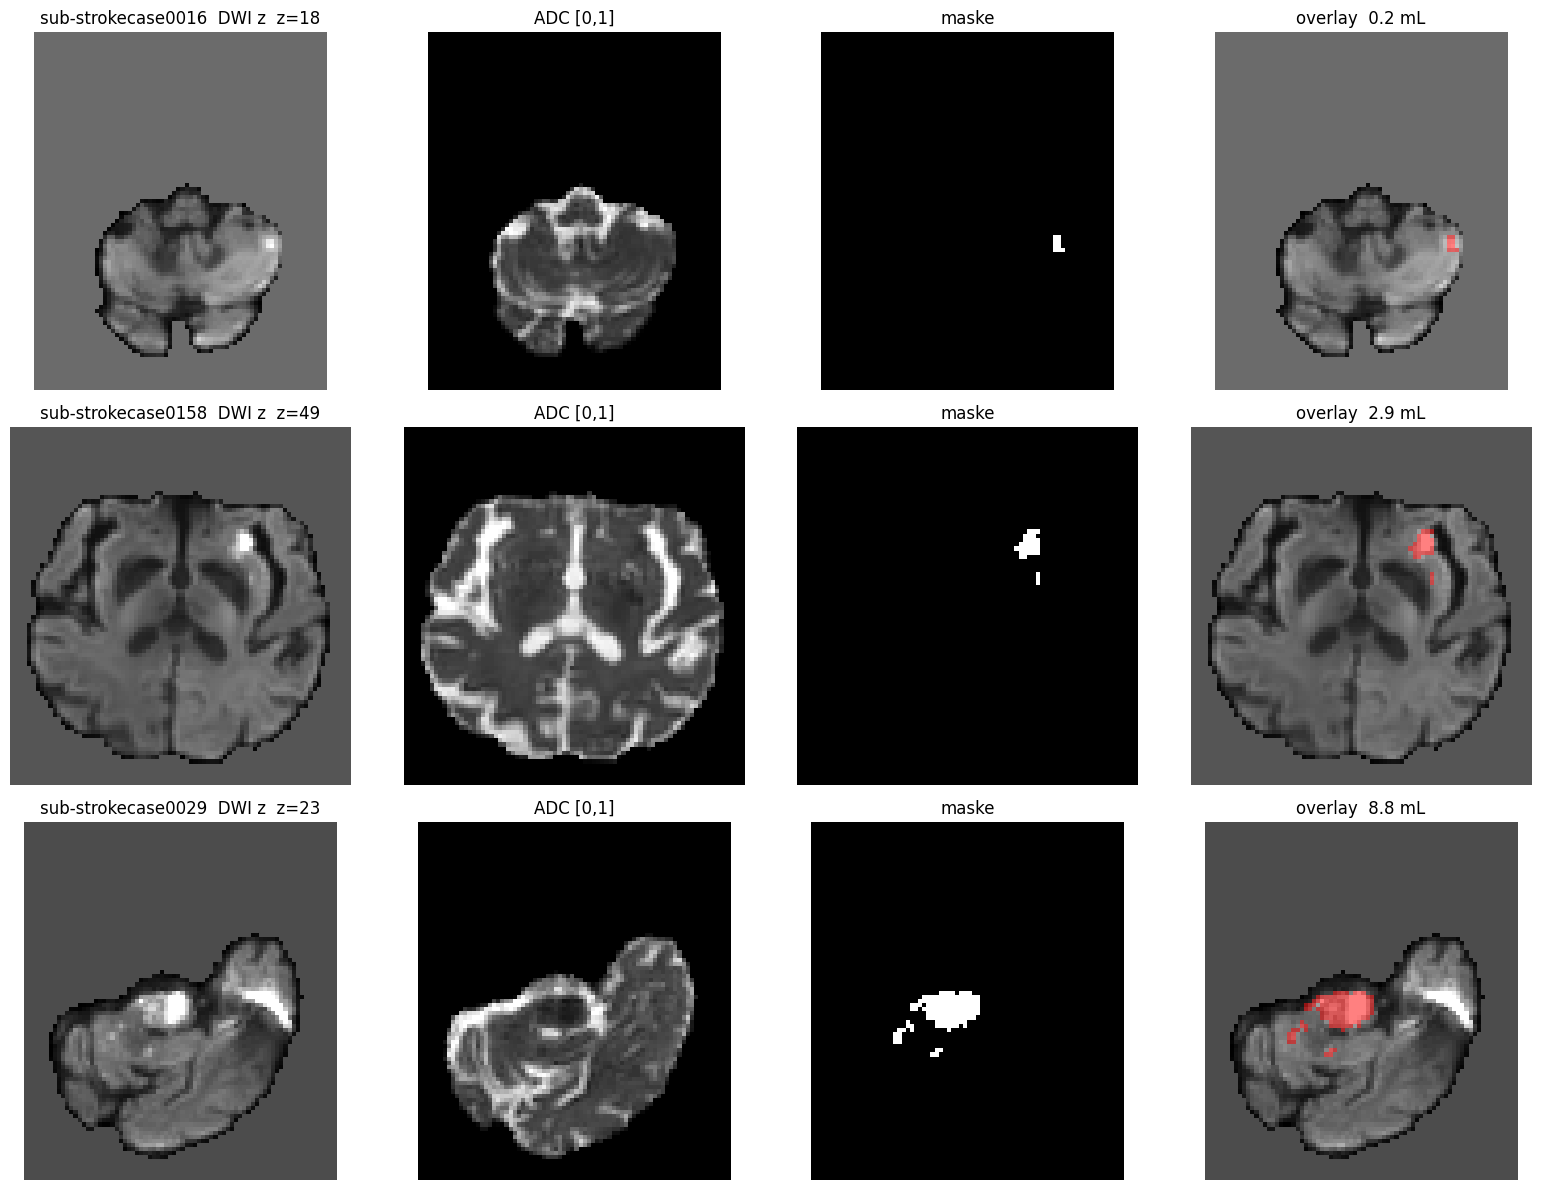

In [15]:
fig, ax = plt.subplots(len(ornek), 4, figsize=(16, 4 * len(ornek)))
for i, v in enumerate(ornek):
    x = np.load(os.path.join(HAZIR, f'{v}_x.npy')).astype(np.float32)
    y = np.load(os.path.join(HAZIR, f'{v}_y.npy'))
    k = int(np.argmax(y.sum(axis=(0, 1))))
    hac = float(man.loc[man.vaka == v, 'hacim_ml'].iloc[0])

    ax[i, 0].imshow(x[0, ..., k].T, cmap='gray', origin='lower'); ax[i, 0].set_title(f'{v}  DWI z  z={k}')
    ax[i, 1].imshow(x[1, ..., k].T, cmap='gray', origin='lower'); ax[i, 1].set_title('ADC [0,1]')
    ax[i, 2].imshow(y[..., k].T, cmap='gray', origin='lower'); ax[i, 2].set_title('maske')
    ax[i, 3].imshow(x[0, ..., k].T, cmap='gray', origin='lower')
    ax[i, 3].imshow(np.ma.masked_where(y[..., k].T == 0, y[..., k].T), cmap='autumn', alpha=.5, origin='lower')
    ax[i, 3].set_title(f'overlay  {hac:.1f} mL')
    for j in range(4):
        ax[i, j].set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(OZET_DIR, 'onisleme_dogrulama.png'), dpi=130, bbox_inches='tight')
plt.show()

In [16]:
ozet2 = dict(
    vaka=len(man),
    onbellek_gb=round(sum(os.path.getsize(os.path.join(HAZIR, f))
                          for f in os.listdir(HAZIR) if f.endswith('.npy')) / 1e9, 2),
    hedef_spacing=list(CFG['hedef_spacing']),
    girdi_H=CFG['girdi_H'],
    girdi_W=CFG['girdi_W'],
    D_medyan=CFG['D_medyan'],
    adc_birim_dagilimi=olcek.birim.value_counts().to_dict(),
    adc_p999_ortak_ort=round(float(olcek.adc_p999_ortak.mean()), 1),
    adc_p999_ortak_cv=round(float(olcek.adc_p999_ortak.std() / olcek.adc_p999_ortak.mean()), 3),
    split={k: len(v) for k, v in split.items()},
    split_merkez=pd.crosstab(man.split, man.merkez).to_dict(),
    hacim_ml_medyan=round(float(man.hacim_ml.median()), 2),
    resample_hacim_farki_ort=round(float(man.hacim_fark_yuzde.mean()), 2),
    bos_maske_vakalar=bos,
    eval_cases=eval_cases,
)
for k, v in ozet2.items():
    print(f'{k:26s} {v}')

with open(os.path.join(OZET_DIR, 'hazirlik_ozeti.json'), 'w', encoding='utf-8') as f:
    json.dump(ozet2, f, indent=2, ensure_ascii=False, default=str)
with pd.ExcelWriter(os.path.join(OZET_DIR, 'hazirlik_ozeti.xlsx')) as w:
    pd.DataFrame([{'olcum': k, 'deger': str(v)} for k, v in ozet2.items()]).to_excel(w, sheet_name='ozet', index=False)
    man.to_excel(w, sheet_name='manifest', index=False)
    olcek.to_excel(w, sheet_name='adc_olcek', index=False)
print('\nyazildi:', OZET_DIR)

vaka                       250
onbellek_gb                1.07
hedef_spacing              [2.0, 2.0, 2.0]
girdi_H                    96
girdi_W                    128
D_medyan                   78
adc_birim_dagilimi         {'mm2/s': 106, 'x10-6': 76, 'x10-3': 68}
adc_p999_ortak_ort         3830.4
adc_p999_ortak_cv          0.088
split                      {'train': 161, 'val': 39, 'test': 50}
split_merkez               {1: {'test': 39, 'train': 128, 'val': 31}, 2: {'test': 11, 'train': 33, 'val': 8}}
hacim_ml_medyan            6.66
resample_hacim_farki_ort   0.01
bos_maske_vakalar          ['sub-strokecase0150', 'sub-strokecase0151', 'sub-strokecase0170']
eval_cases                 ['sub-strokecase0016', 'sub-strokecase0158', 'sub-strokecase0029', 'sub-strokecase0192', 'sub-strokecase0031']

yazildi: /content/drive/MyDrive/iskemik_inme/ozet


---

# Parca 2b - FLAIR hazirlama (A1 ablasyonu icin)

Parca 1 olcumu: **FLAIR 0/250 vakada DWI ile ayni grid'de**. 22 farkli sekil, 21 farkli spacing,
voxel hacmi 0,055-4,43 mm3. Kullanabilmek icin vaka basina hizalama gerekiyor.

**Yontem: header tabanli yeniden ornekleme.** Iki seri ayni oturumda cekildigi icin NIfTI
affine'leri ortak tarayici uzayini tanimliyor; `resample_from_to` FLAIR'i DWI grid'ine bu
affine'ler uzerinden tasiyor. **Yogunluk tabanli kayit (registration) yapilmiyor.**

> **Sinirlilik - rapora yazilacak.** ISLES'22 makalesi FLAIR'in referans cerceveden "hafifce
> kaymis" oldugunu soyluyor. Header tabanli tasima hasta hareketini duzeltmez; artik kayma
> kalabilir. Yani A1 ablasyonu "FLAIR'in katkisi"ni degil, **"ucuz hizalamayla FLAIR'in
> katkisi"ni** olcuyor. Sonuc negatif cikarsa bu, FLAIR'in bilgi tasimadigi anlamina gelmez.

Cikti: `hazir/<vaka>_f.npy` (1, h, w, d) - `_x.npy` ile **ayni grid ve ayni kirpma**.
Ayrica hizalamanin **vaka basina ms maliyeti** olculuyor; Bolum 3 gecikme butcesine yazilacak.

In [17]:
from nibabel.processing import resample_from_to

def flair_bul(vaka):
    kalip = os.path.join(DATA_ROOT, '**', f'*{vaka}*FLAIR.nii.gz')
    b = sorted(glob.glob(kalip, recursive=True))
    if not b:
        b = [q for q in NII if vaka in q and 'flair' in os.path.basename(q).lower()]
    return b[0] if b else None

dosya['flair'] = [flair_bul(v) for v in dosya.vaka]
print('FLAIR bulunan:', dosya.flair.notna().sum(), '/', len(dosya))
eksik_f = dosya[dosya.flair.isna()]
if len(eksik_f):
    print('EKSIK:', eksik_f.vaka.tolist())

FLAIR bulunan: 250 / 250


In [18]:
def flair_hazirla(r):
    '''FLAIR'i DWI grid'ine tasi, _x.npy ile ayni resample + kirpmadan gecir, normalize et.

    Kirpma kutusu Parca 2'deki ile birebir ayni cikmali: ayni DWI'dan, ayni esikle,
    ayni beyin maskesi fonksiyonuyla hesaplaniyor (deterministik).'''
    dwi_im = nib.load(r.dwi)
    fl_im = nib.load(r.flair)

    t0 = time.time()
    fl_dwi = resample_from_to(fl_im, dwi_im, order=1)          # <-- olculen hizalama adimi
    hizalama_sn = time.time() - t0

    hs = CFG['hedef_spacing']
    dw = np.asarray(resample_to_output(dwi_im, hs, order=CFG['resample_order_goruntu']).dataobj).astype(np.float32)
    fl = np.asarray(resample_to_output(fl_dwi, hs, order=CFG['resample_order_goruntu']).dataobj).astype(np.float32)
    assert dw.shape == fl.shape, f'{r.vaka}: {dw.shape} vs {fl.shape}'

    b = beyin_maskesi(dw)
    idx = np.where(b)
    m = CFG['kirpma_marji']
    dilim = tuple(slice(max(int(i.min()) - m, 0), min(int(i.max()) + 1 + m, s))
                  for i, s in zip(idx, dw.shape))
    fl, b = fl[dilim], b[dilim]

    ort, std = float(fl[b].mean()), float(fl[b].std()) + 1e-6   # DWI ile ayni: maske ici z-score
    fl = np.clip((fl - ort) / std, -CFG['dwi_z_klip'], CFG['dwi_z_klip'])
    fl[~b] = 0.0
    return fl[None].astype(CFG['dtype_goruntu']), hizalama_sn, fl.shape


# tek vakada dogrula: sekil _x.npy ile birebir ayni olmali
r0 = dosya.iloc[0]
f0, sn0, sekil0 = flair_hazirla(r0)
x0 = np.load(os.path.join(HAZIR, f'{r0.vaka}_x.npy'))
print(f'{r0.vaka}: FLAIR {f0.shape} | mevcut _x.npy {x0.shape} | hizalama {sn0*1000:.0f} ms')
assert f0.shape[1:] == x0.shape[1:], f'sekil uyusmuyor: {f0.shape[1:]} vs {x0.shape[1:]}'
print('sekil ve kirpma _x.npy ile BIREBIR ayni')

sub-strokecase0001: FLAIR (1, 72, 85, 74) | mevcut _x.npy (2, 72, 85, 74) | hizalama 2886 ms
sekil ve kirpma _x.npy ile BIREBIR ayni


In [19]:
sureler, hatalar = [], []
t0 = time.time()
for i, r in dosya.iterrows():
    try:
        f, sn, _ = flair_hazirla(r)
        x = np.load(os.path.join(HAZIR, f'{r.vaka}_x.npy'))
        assert f.shape[1:] == x.shape[1:], f'{r.vaka}: {f.shape[1:]} vs {x.shape[1:]}'
        np.save(os.path.join(HAZIR, f'{r.vaka}_f.npy'), f)
        sureler.append(dict(vaka=r.vaka, hizalama_sn=sn))
    except Exception as e:
        hatalar.append((r.vaka, repr(e)))
        print('HATA', r.vaka, repr(e))
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(dosya)}  ({time.time()-t0:.0f} sn)')

hz = pd.DataFrame(sureler)
print(f'\nhazirlanan: {len(hz)} / {len(dosya)} | hata: {len(hatalar)}')
print(f'toplam {time.time()-t0:.0f} sn')
print('\n--- hizalama maliyeti (vaka basina) ---')
print(hz.hizalama_sn.describe().to_string())
print(f'\nMEDYAN {hz.hizalama_sn.median()*1000:.0f} ms/vaka  <- Bolum 3 gecikme butcesine yazilacak')
print(f'Karsilastirma: unet3d tam cikarim ~80 ms/vaka. Yani FLAIR hizalamasi tek basina'
      f' cikarimin {hz.hizalama_sn.median()*1000/80:.1f} katina mal oluyor.')

  50/250  (178 sn)
  100/250  (368 sn)
  150/250  (554 sn)
  200/250  (703 sn)
  250/250  (859 sn)

hazirlanan: 250 / 250 | hata: 0
toplam 859 sn

--- hizalama maliyeti (vaka basina) ---
count    250.000000
mean       1.654821
std        0.956761
min        0.044653
25%        1.084093
50%        1.783698
75%        2.276469
max        4.903180

MEDYAN 1784 ms/vaka  <- Bolum 3 gecikme butcesine yazilacak
Karsilastirma: unet3d tam cikarim ~80 ms/vaka. Yani FLAIR hizalamasi tek basina cikarimin 22.3 katina mal oluyor.


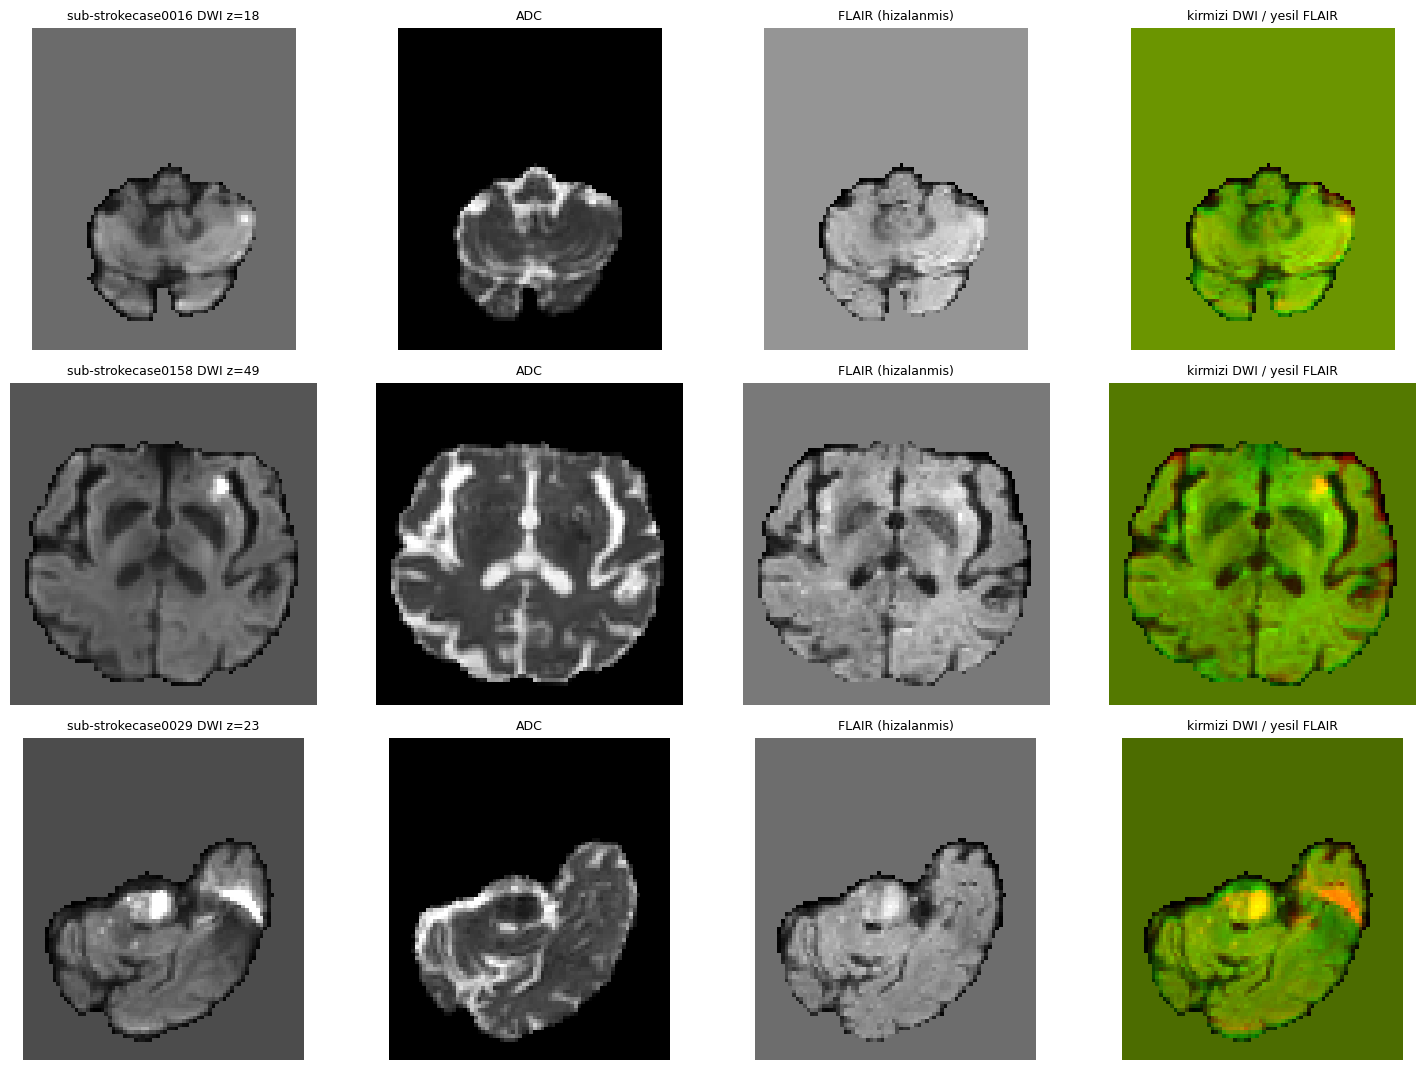

Beyin sinirlari ust uste dusmuyorsa header tabanli tasima yetersiz demektir;
o durumda yogunluk tabanli kayit gerekir ve A1 sonucu buna gore yorumlanmalidir.


In [20]:
# Gorsel dogrulama: FLAIR gercekten DWI ile ortusuyor mu
ornek = json.load(open(os.path.join(PROJE, 'eval_cases.json')))[:3]
fig, ax = plt.subplots(len(ornek), 4, figsize=(15, 3.6 * len(ornek)))
for i, v in enumerate(ornek):
    x = np.load(os.path.join(HAZIR, f'{v}_x.npy')).astype(np.float32)
    f = np.load(os.path.join(HAZIR, f'{v}_f.npy')).astype(np.float32)
    y = np.load(os.path.join(HAZIR, f'{v}_y.npy'))
    z = int(np.argmax(y.sum(axis=(0, 1)))) if y.any() else y.shape[2] // 2

    ax[i, 0].imshow(x[0, :, :, z].T, cmap='gray', origin='lower'); ax[i, 0].set_title(f'{v} DWI z={z}', fontsize=9)
    ax[i, 1].imshow(x[1, :, :, z].T, cmap='gray', origin='lower'); ax[i, 1].set_title('ADC', fontsize=9)
    ax[i, 2].imshow(f[0, :, :, z].T, cmap='gray', origin='lower'); ax[i, 2].set_title('FLAIR (hizalanmis)', fontsize=9)
    # ortusme kontrolu: DWI kirmizi, FLAIR yesil - beyin sinirlari cakismali
    rgb = np.zeros((*x[0, :, :, z].T.shape, 3))
    nrm = lambda a: (a - a.min()) / (np.ptp(a) + 1e-6)   # ndarray.ptp NumPy 2.0'da kaldirildi
    rgb[..., 0] = nrm(x[0, :, :, z].T); rgb[..., 1] = nrm(f[0, :, :, z].T)
    ax[i, 3].imshow(rgb, origin='lower'); ax[i, 3].set_title('kirmizi DWI / yesil FLAIR', fontsize=9)
    for j in range(4):
        ax[i, j].set_axis_off()
plt.tight_layout()
plt.savefig(os.path.join(OZET_DIR, 'flair_hizalama.png'), dpi=130, bbox_inches='tight')
plt.show()
print('Beyin sinirlari ust uste dusmuyorsa header tabanli tasima yetersiz demektir;')
print('o durumda yogunluk tabanli kayit gerekir ve A1 sonucu buna gore yorumlanmalidir.')

In [21]:
hz.to_excel(os.path.join(OZET_DIR, 'flair_hizalama.xlsx'), index=False)
onbellek = sum(os.path.getsize(os.path.join(HAZIR, q))
               for q in os.listdir(HAZIR) if q.endswith('.npy')) / 1e9
print(f'toplam onbellek: {onbellek:.2f} GB (FLAIR dahil)')
print(f'FLAIR dosyasi: {len([q for q in os.listdir(HAZIR) if q.endswith("_f.npy")])}')
print('\nPARCA 2b TAMAM - A1_flair kosulabilir.')

toplam onbellek: 1.07 GB (FLAIR dahil)
FLAIR dosyasi: 250

PARCA 2b TAMAM - A1_flair kosulabilir.
